In [1]:
"""
"""

'\n'

In [2]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import fft_deconvolve
import scipy
from scipy.linalg import circulant
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

import torch

In [3]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
print('Pulse Peak Offset:', np.argmax(pulse))

peak_offset_samples = np.argmax(pulse)
peak_offset_time = pulse_times[peak_offset_samples]

Pulse Peak Offset: 9


100 100 100
(102,)
kernel sum 12.866493980555823
Trace Size: 4100


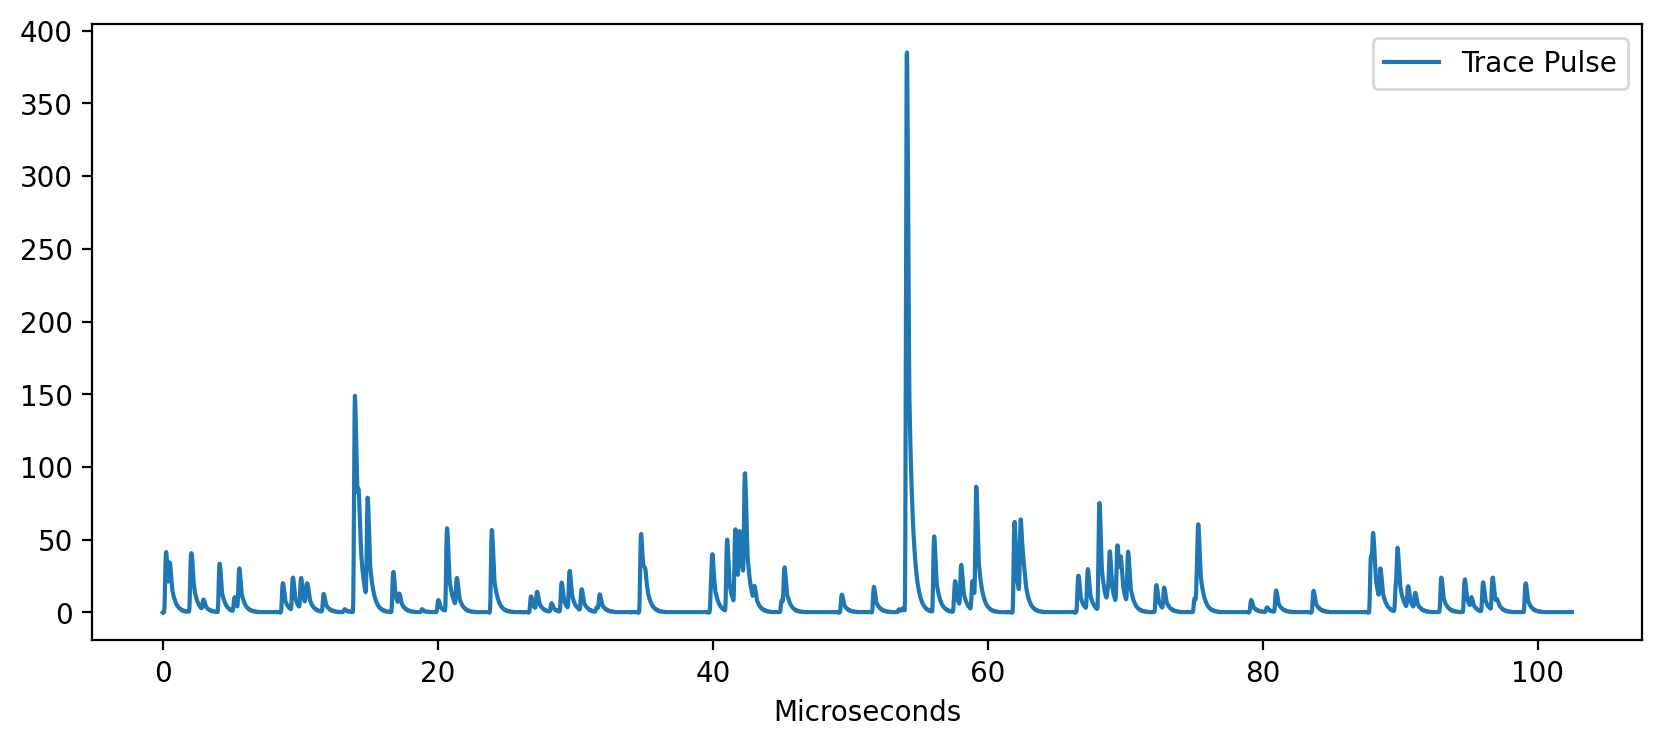

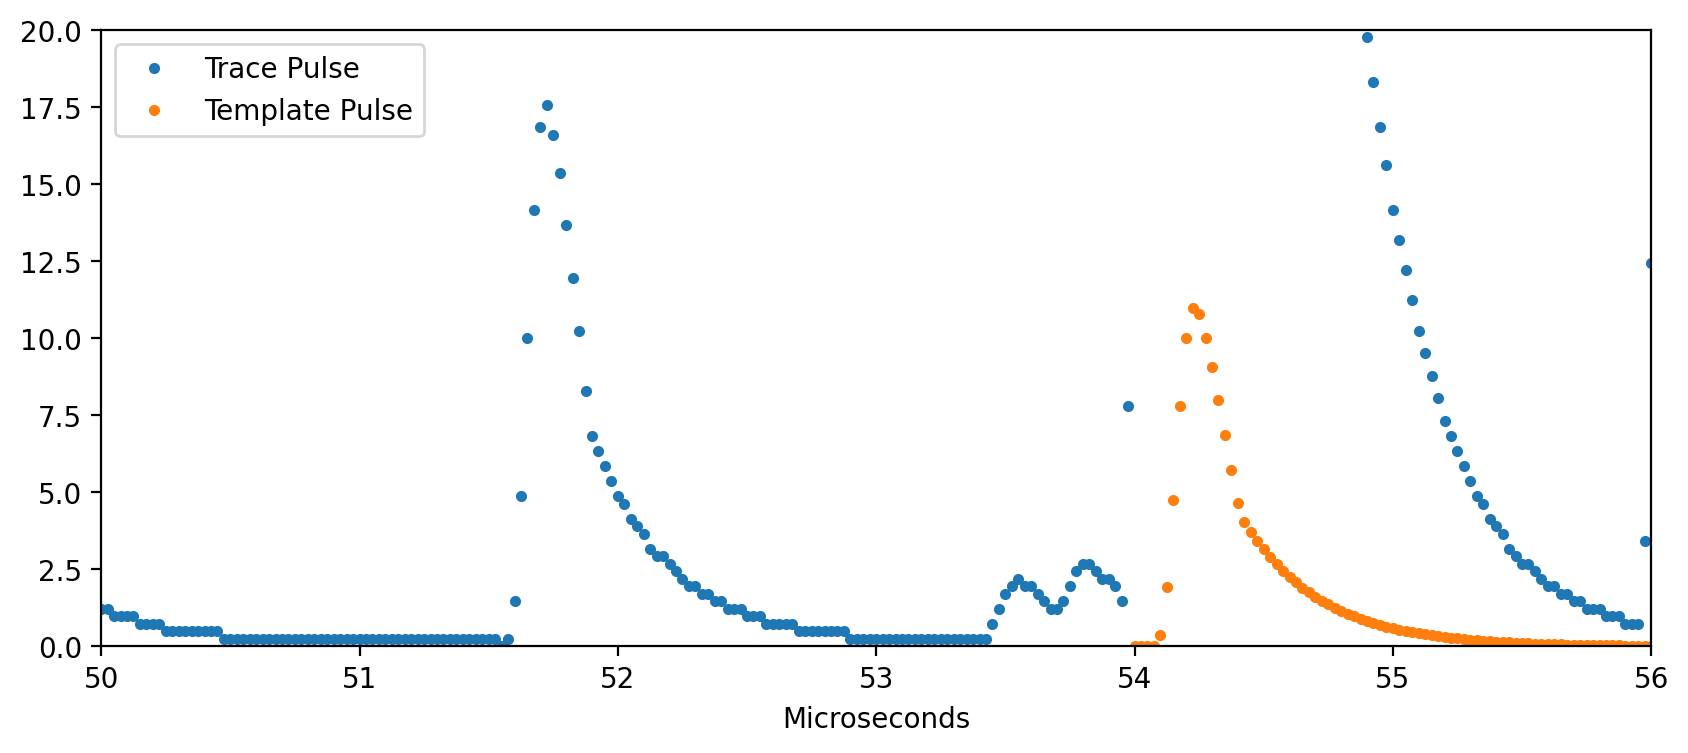

In [4]:
#determined by trial and error to match energy range of instrument on THOR data.
# modified for sampling rate difference with HERA

keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise = 0 # mV
bits = 12
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 1E-4
count_rate = 1E6

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = '../original/NaI_Response'
spectrum = np.loadtxt(response_file,usecols=(1),dtype=float) # histogram density, unitless
binenergies = np.loadtxt(response_file,usecols=(0),dtype=float) * 1e3 # [KeV]

# 2000E6 seems right at the moment, but why?
out = continuous_time_trace(pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=count_rate, total_time=total_time, trace_type='constant', spectrum_interp_bins=4,
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=baseline, basenoise=basenoise, bits=bits, clip_magnitude=clip, 
                            seed=1,)

trace, sample_t, sample_index, event_voltages, event_energies, event_times = out

print('Trace Size:', trace.size)

trace_gt0 = trace[trace>0]

fig = plt.figure(figsize=(10,4), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
# plt.plot(1E6*interp_time, interp_pulse * np.max(trace), '.', markersize=1, alpha=.5, label='Interp Pulse')
plt.xlabel('Microseconds')
plt.legend()

if event_voltages.size < 20:
    microseconds = 1E6*(event_times+peak_offset_time)
    plt.plot(microseconds, event_voltages, 'r.', label='Ground Truth Peaks')
    for i in range(event_times.size):
        
        t = microseconds[i] + 1
        v = event_voltages[i]
        plt.text(t,v, 'T={:.3f}'.format(t))
        

plt.figure(figsize=(10,4), dpi=200)
plt.plot(1E6*sample_t, trace, marker='.', linestyle='', label='Trace Pulse')
plt.xlabel('Microseconds')
plt.legend()
plt.xlim(50, 56)
plt.ylim(0, 20)
plt.plot(pulse_times*1E6+54, 11 *  pulse, marker='.', linestyle='', label='Template Pulse')
plt.legend()

unique = np.unique(trace)
diff = np.diff(unique)[:30]
diff = np.round(diff, 6)
assert np.all(diff[0] == diff)
assert int(np.round(np.log2(1000/diff[0]))) == bits
# If correct diff: 1000 / 2^x = diff


100 4100
4100 (4100, 4100)


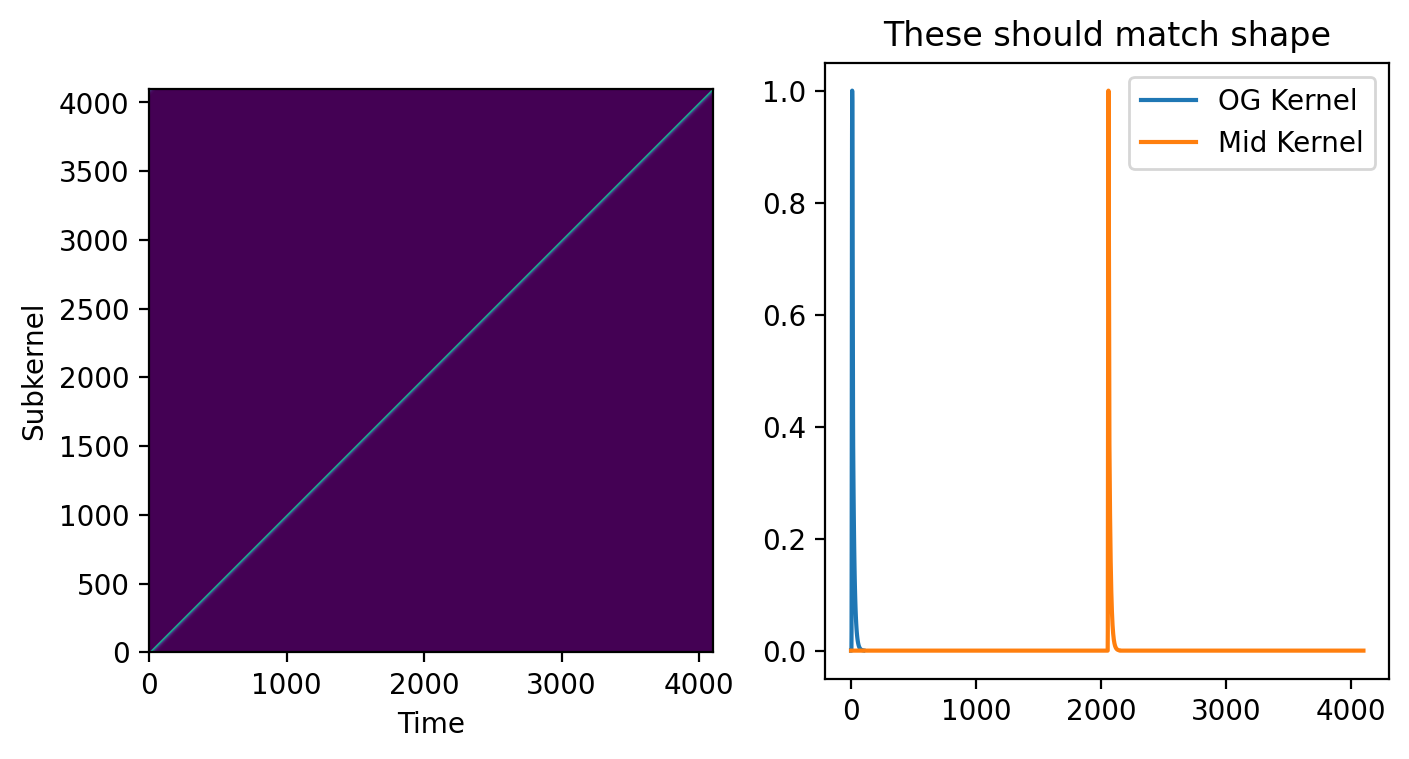

In [5]:
def dense_double_padded_circulant(kernel, size, show=False):
    # Produces C of shape [Time, channels]. Unforunately, Time=channels
    # so plotting is used to double-check they are correct...

    assert size > kernel.size
    print(kernel.size, size)
    # Square matrix
    # assuming it is to be used with double padded trace
    C_ = circulant(np.concatenate((kernel, np.zeros(size - kernel.size))))

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=200)
        axes[0].imshow(C_.T, origin='lower')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Subkernel')

        axes[1].plot(kernel, label='OG Kernel')
        # needs to be [time, kernel n]
        axes[1].plot(C_[:, C_.shape[1] // 2], label='Mid Kernel')  # all time for middle kernel
        axes[1].set_title('These should match shape')
        axes[1].legend()

    return C_

C_numpy = dense_double_padded_circulant(pulse, trace.size, show=True)
print(trace.size, C_numpy.shape)

class ExpPosLinear(torch.nn.Module):
    def __init__(self, size):
        super().__init__()
        self.z = torch.nn.Parameter(torch.zeros(size, dtype=torch.double))

    def forward(self, c):
        return c @ torch.exp(self.z)
    
    def set_weights(self, x, device=None):
        if device:
            self.z = torch.nn.Parameter(torch.log(torch.tensor(x).to(device)))
        else:
            self.z = torch.nn.Parameter(torch.log(torch.tensor(x)))
            
    def linear_mag(self, detach=True):
        if detach:
            x = torch.exp(self.z.detach().cpu())
        else:
            x = torch.exp(self.z)
        return x

model = ExpPosLinear(trace.size)

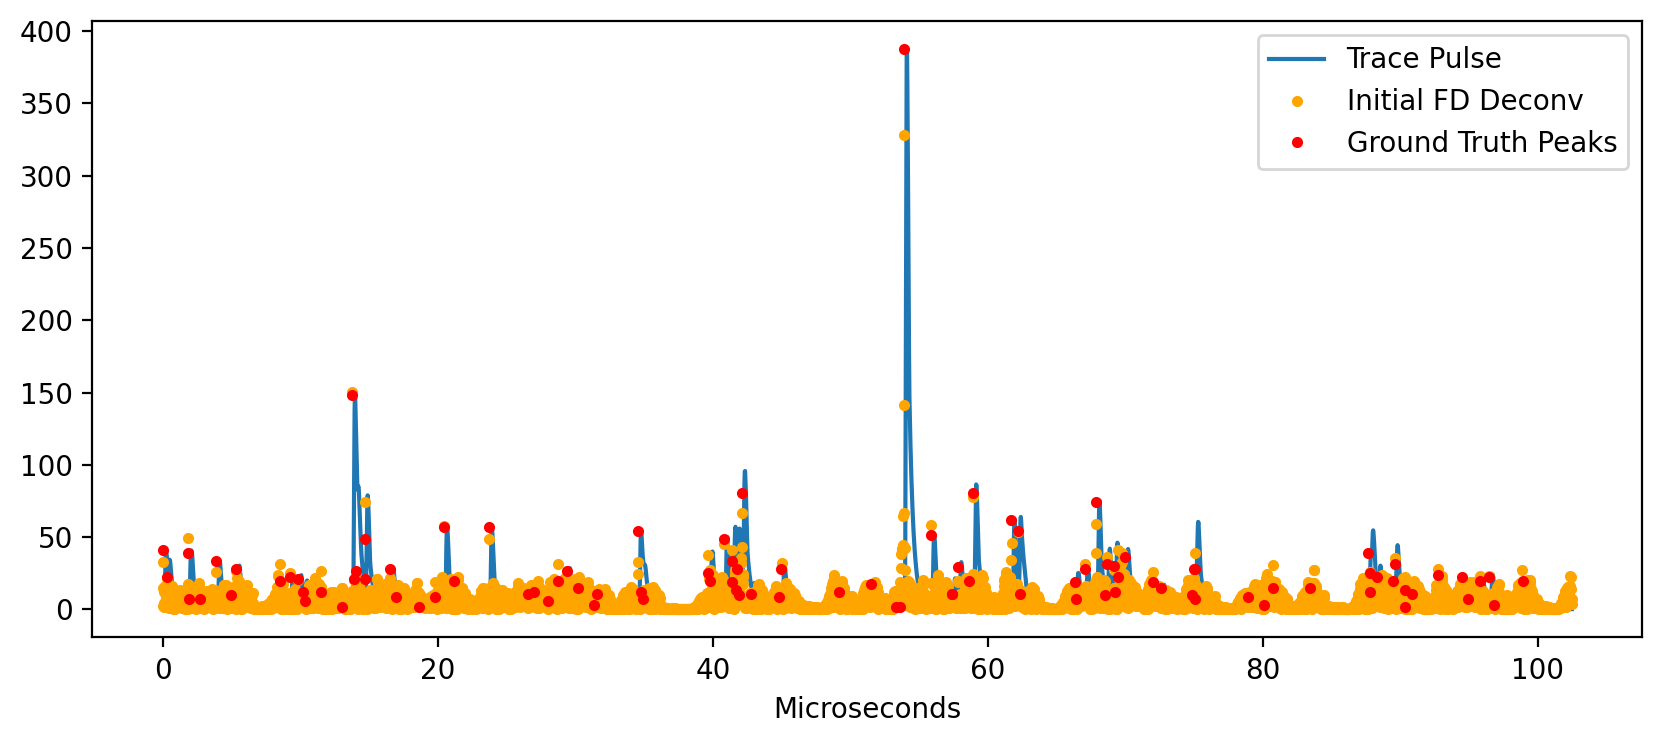

In [6]:
# find intial solutoin with FD Deconv
deconv0 = fft_deconvolve(trace, pulse)

fig = plt.figure(figsize=(10,4), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
plt.plot(1E6*sample_t, deconv0, marker='.', linestyle='', color='orange', label='Initial FD Deconv')
plt.plot(1E6*event_times+peak_offset_time, event_voltages, 'r.', label='Ground Truth Peaks')
plt.plot()
plt.xlabel('Microseconds')
plt.legend()



0 51320.33769679226
100 47453.09123213884
200 44057.271955908356
300 41009.380421368965
400 38234.34784385908
500 35677.25537428847
600 33308.82867075641
700 31096.54405651732
800 29043.504595264247
900 27143.88049856981
1000 25380.708965723694
1100 23743.82905773449
1200 22211.504393250783
1300 20770.24188521826
1400 19417.301965241757
1500 18128.761024475345
1600 16907.72218952589
1700 15769.125798251811
1800 14745.635289646616
1900 13789.883920440323
2000 12903.007835017252
2100 12073.840636036413
2200 11316.537828094375
2300 10615.870664166823
2400 9970.644077705278
2500 9374.757883670856
2600 8818.101347516746
2700 8300.9305724761
2800 7834.044564328113
2900 7402.2785630213575
3000 7000.346355243333
3100 6622.57789032959
3200 6264.787448692174
3300 5923.940352565238
3400 5611.1838275911505
3500 5321.021392637478
3600 5049.037391356967
3700 4792.872366458126
3800 4551.81459569495
3900 4324.407040995769
4000 4108.956549502887
4100 3906.198208408731
4200 3715.751679759839
4300 3535.5

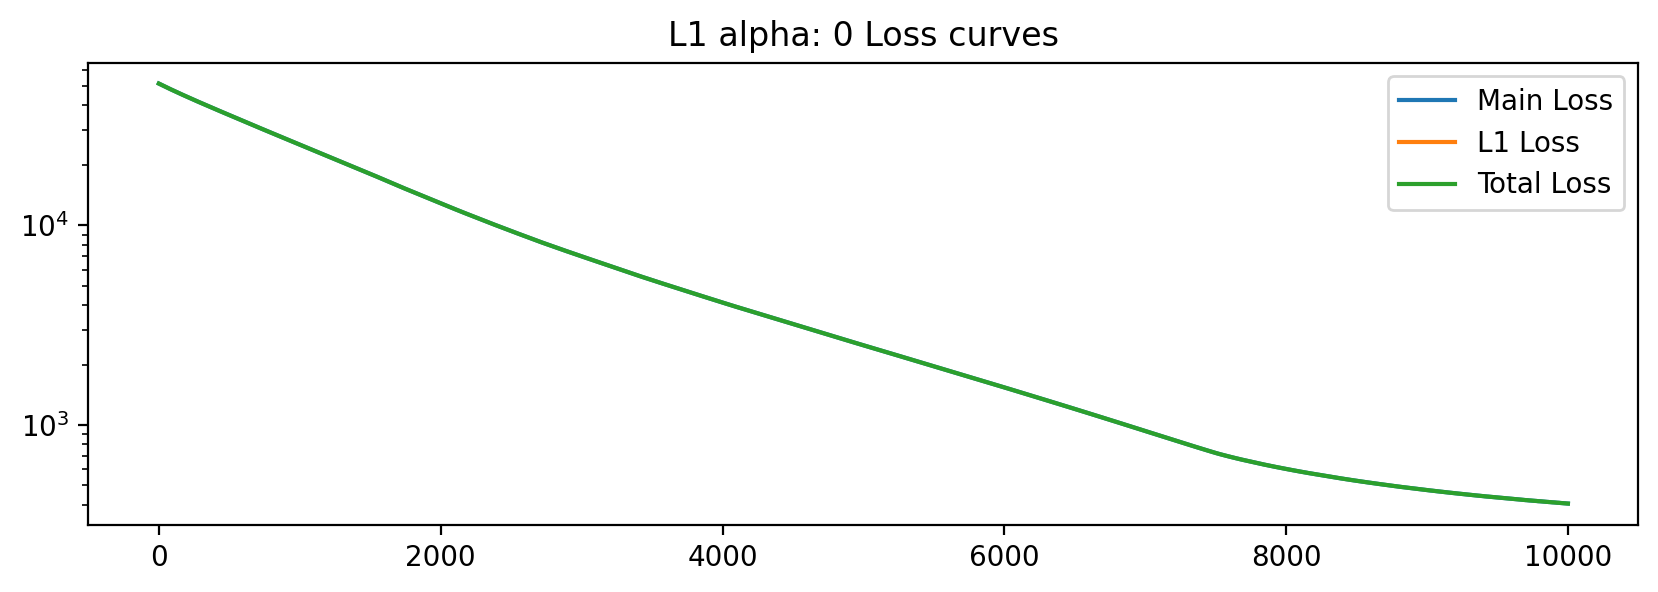

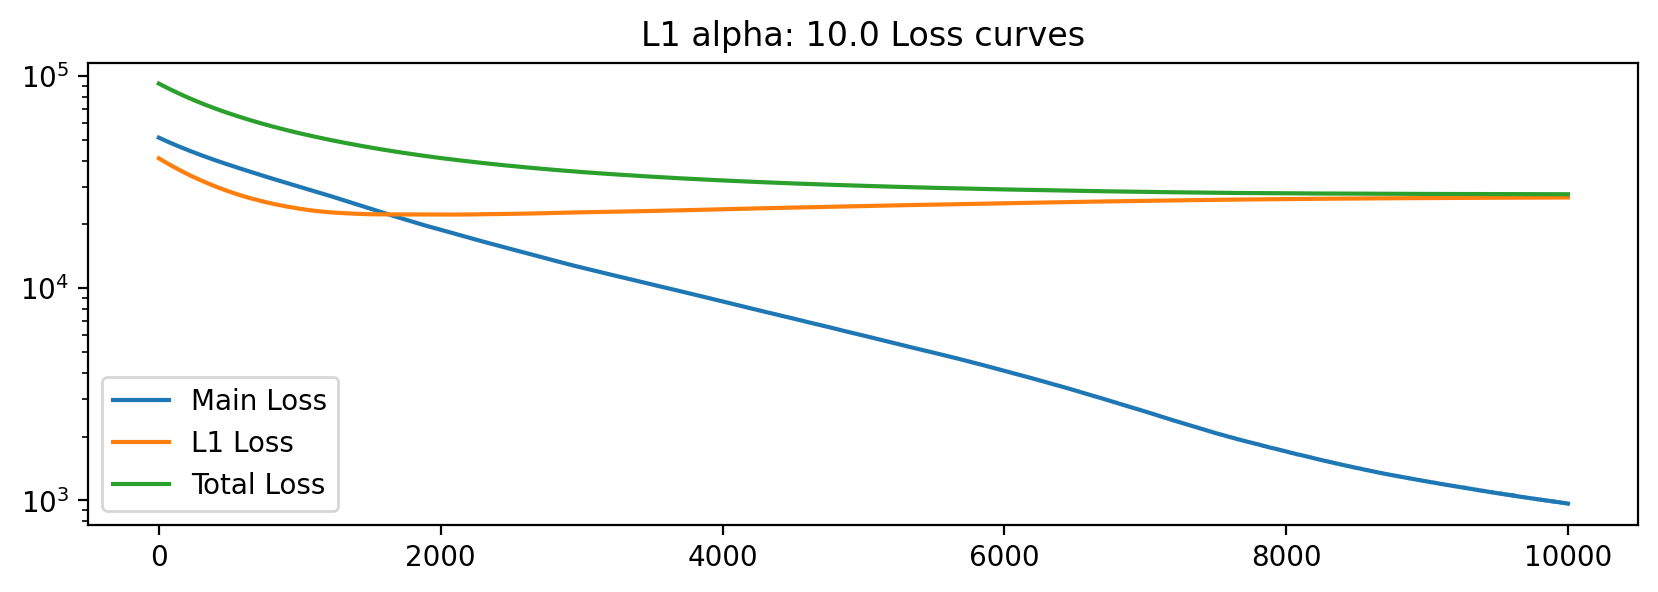

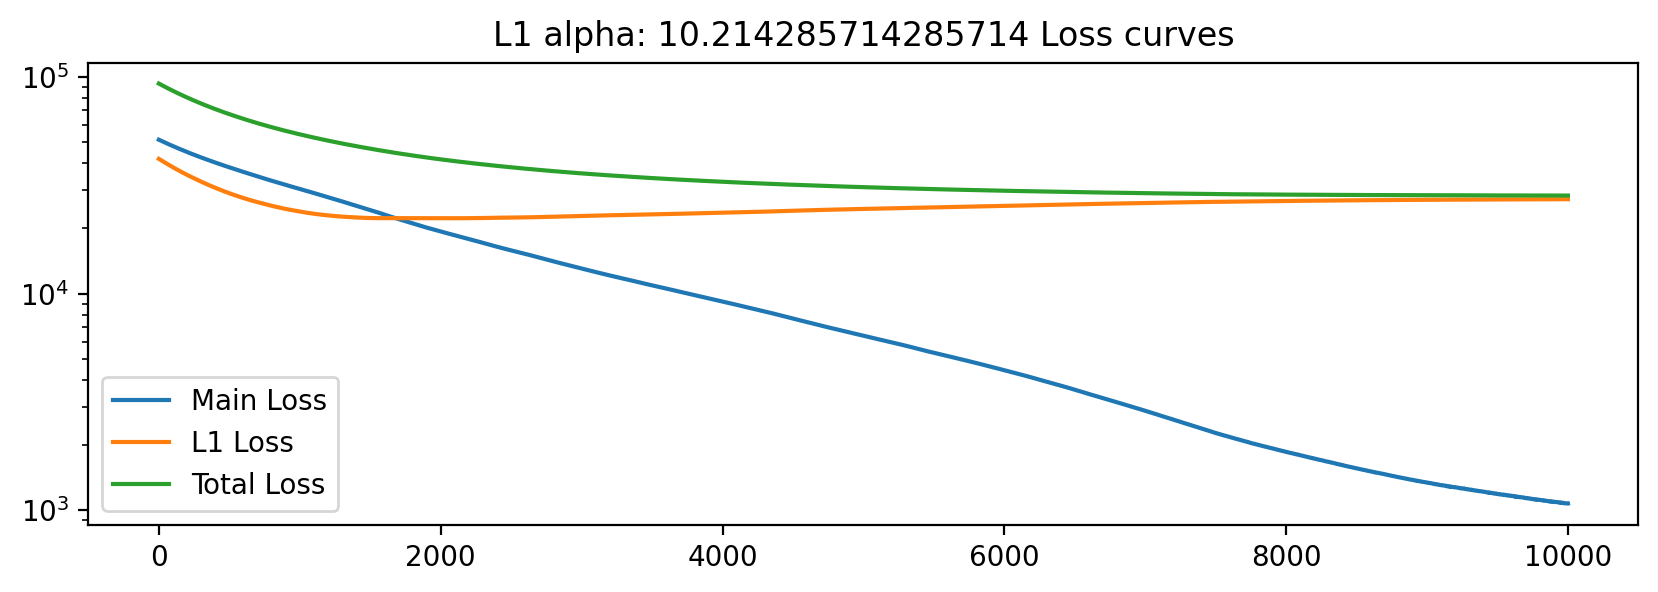

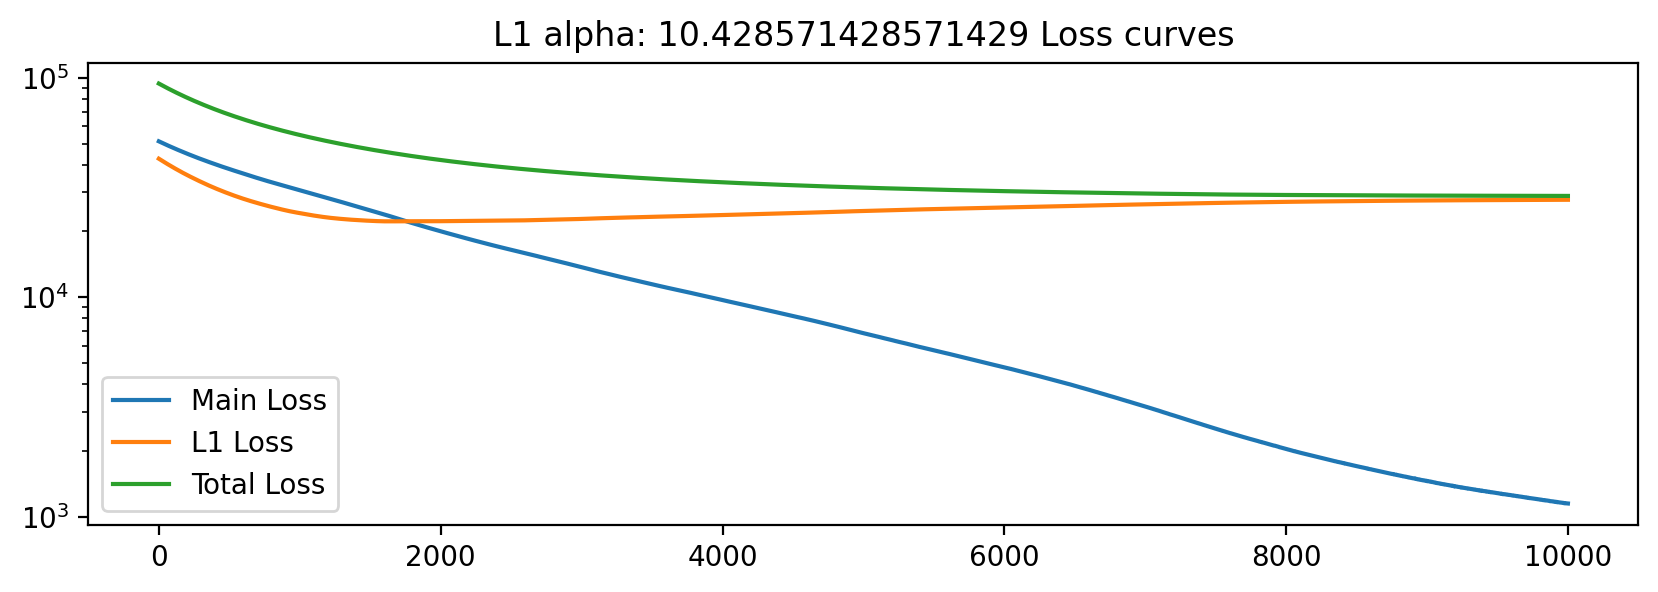

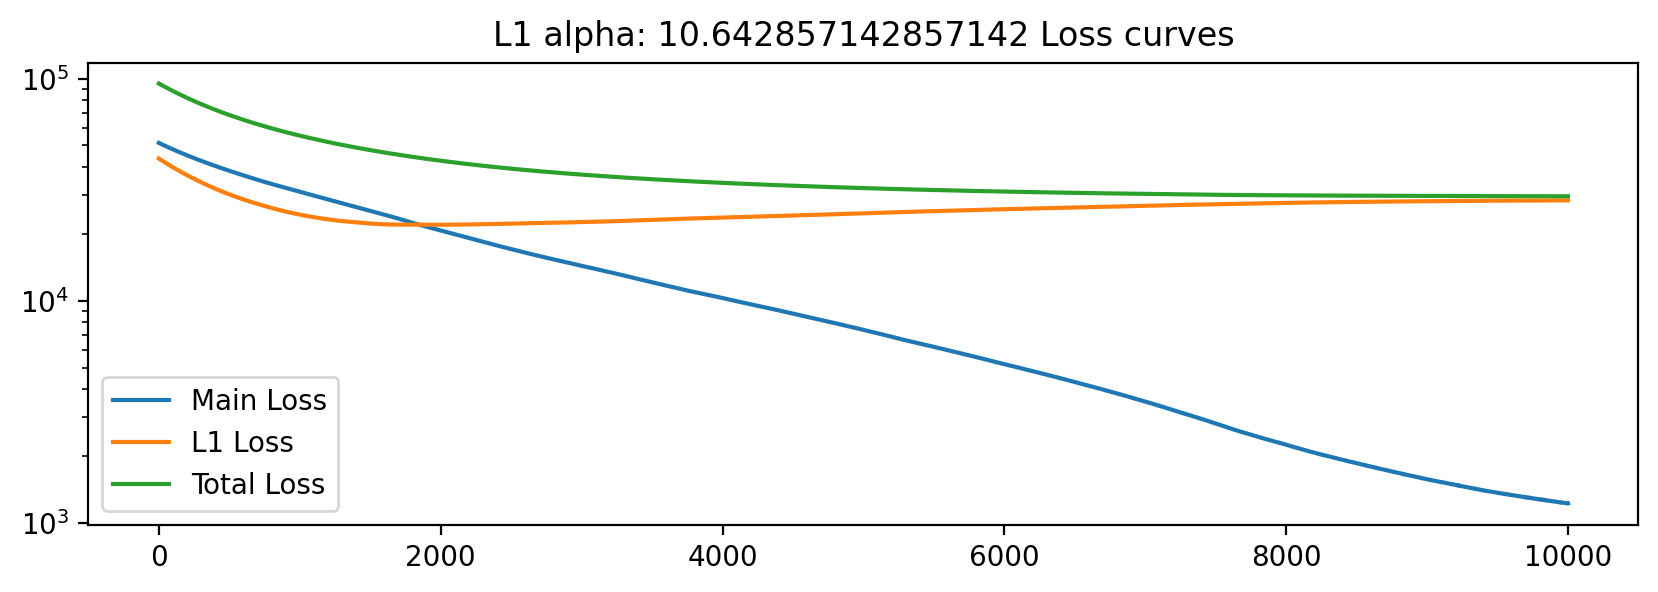

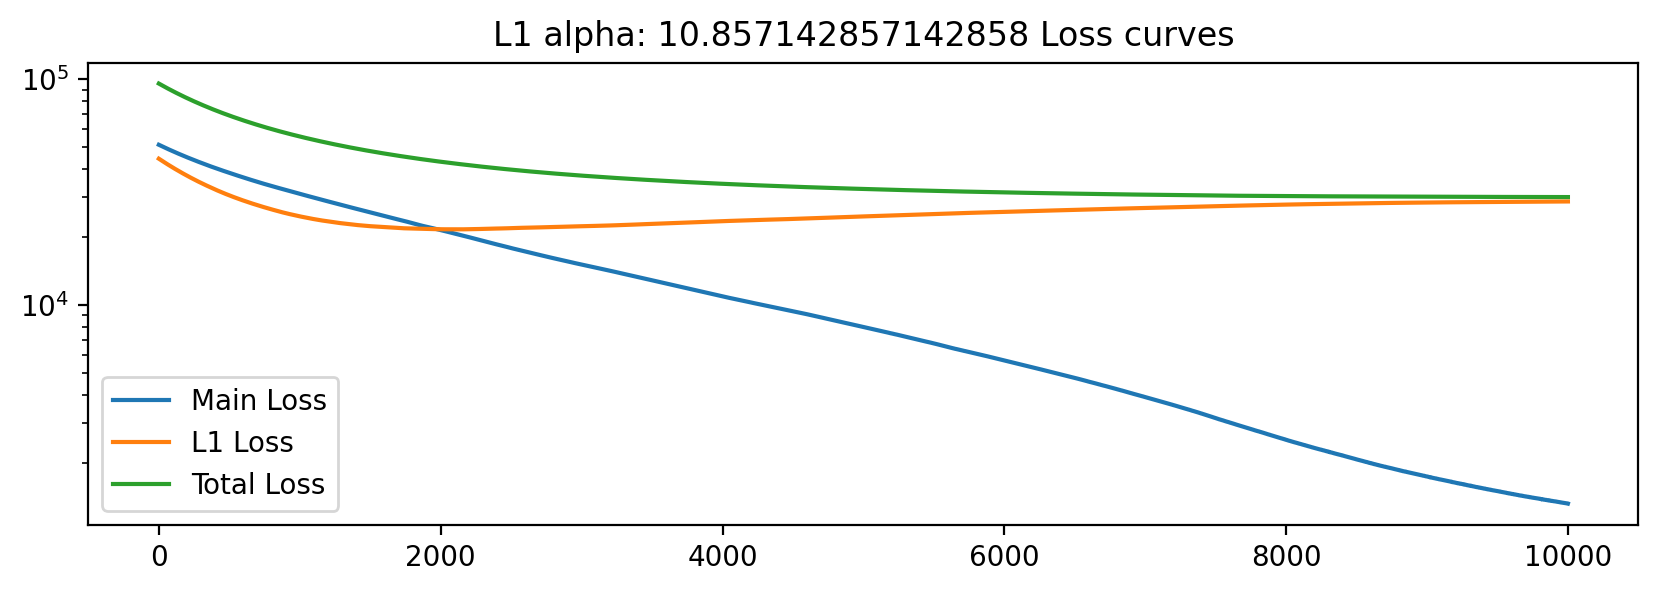

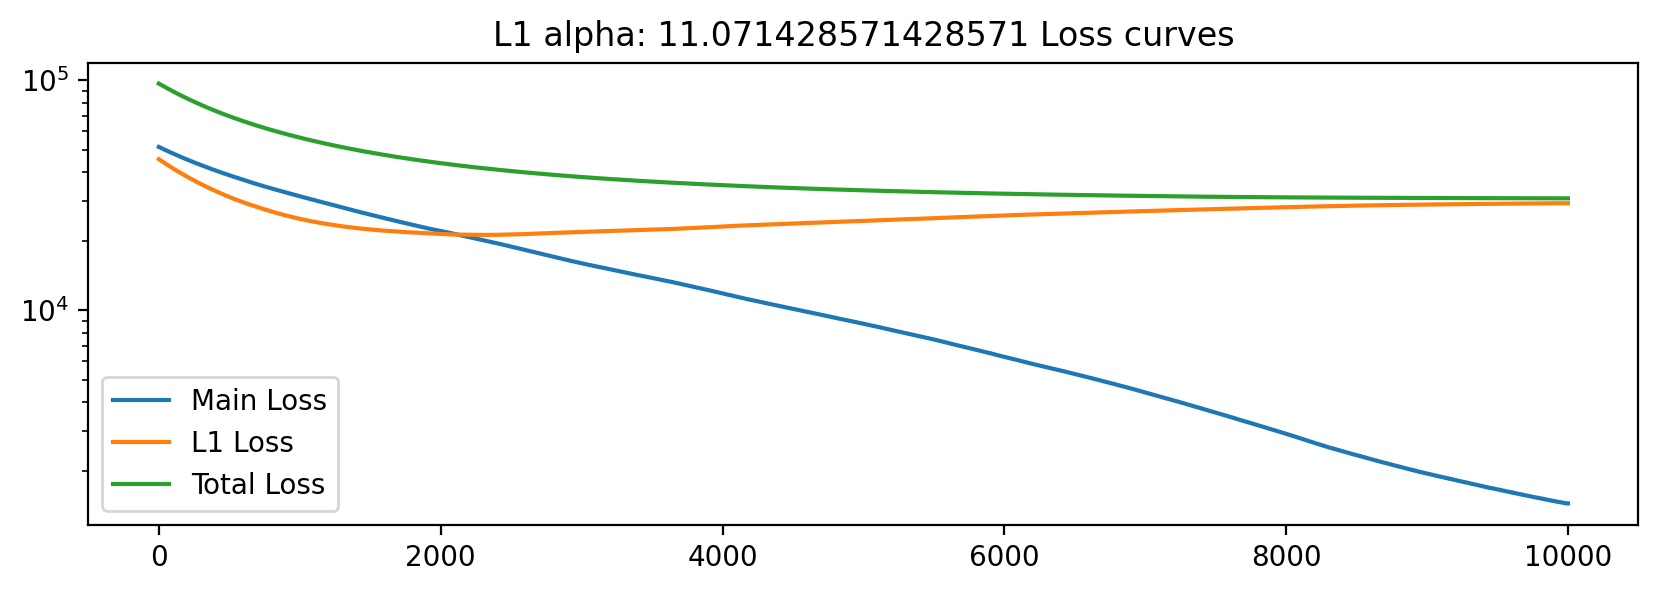

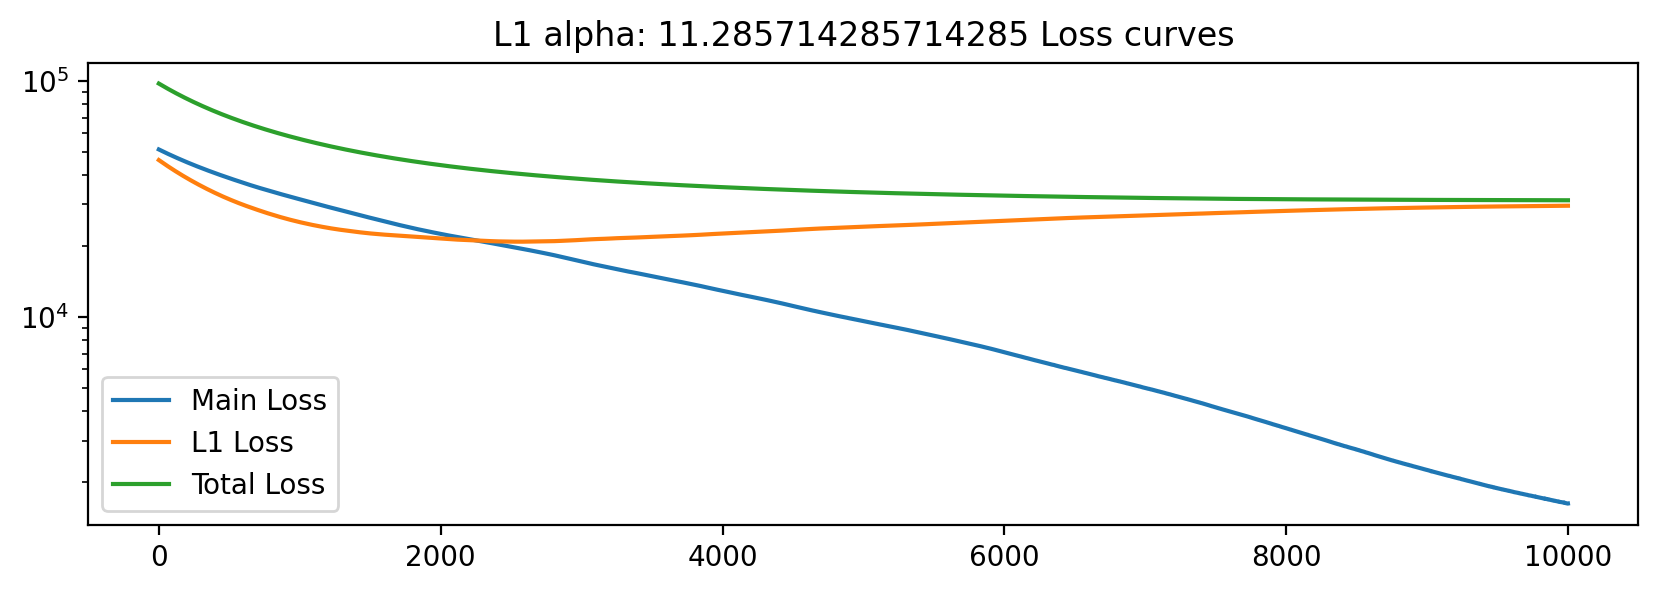

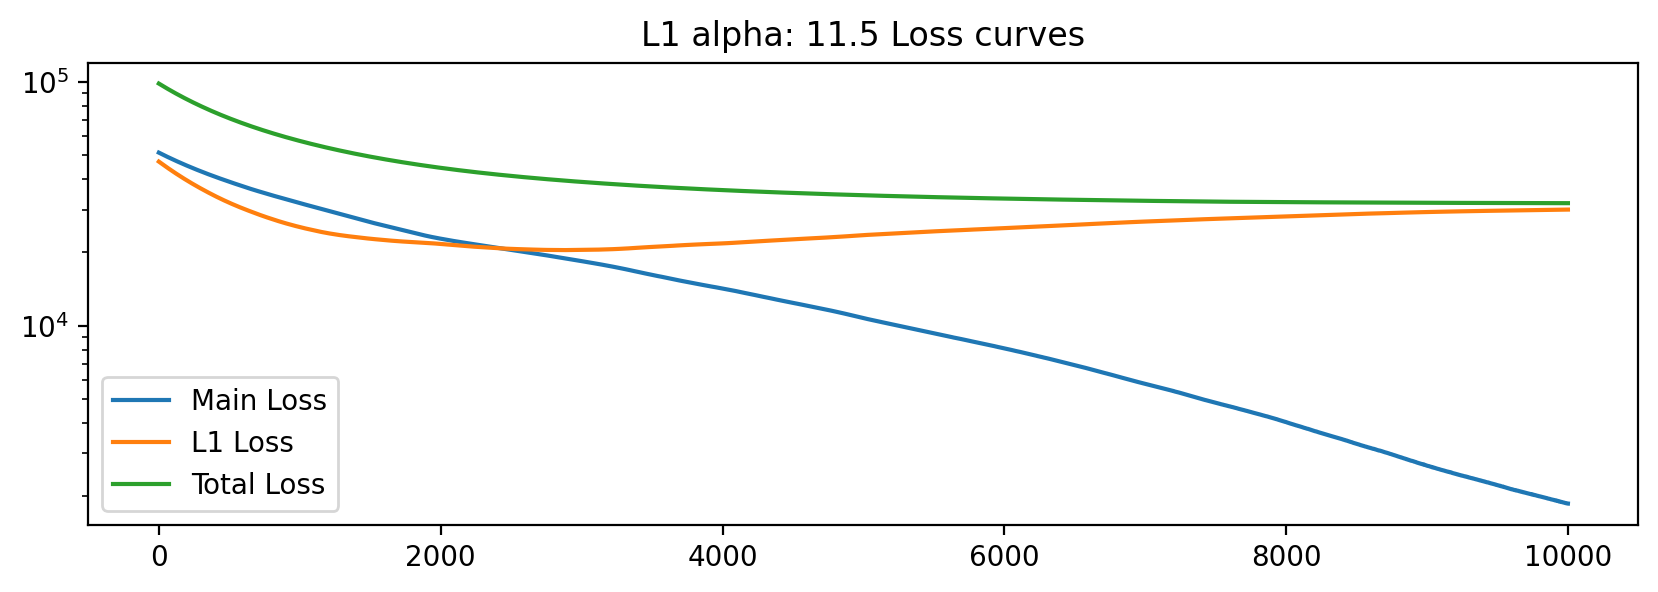

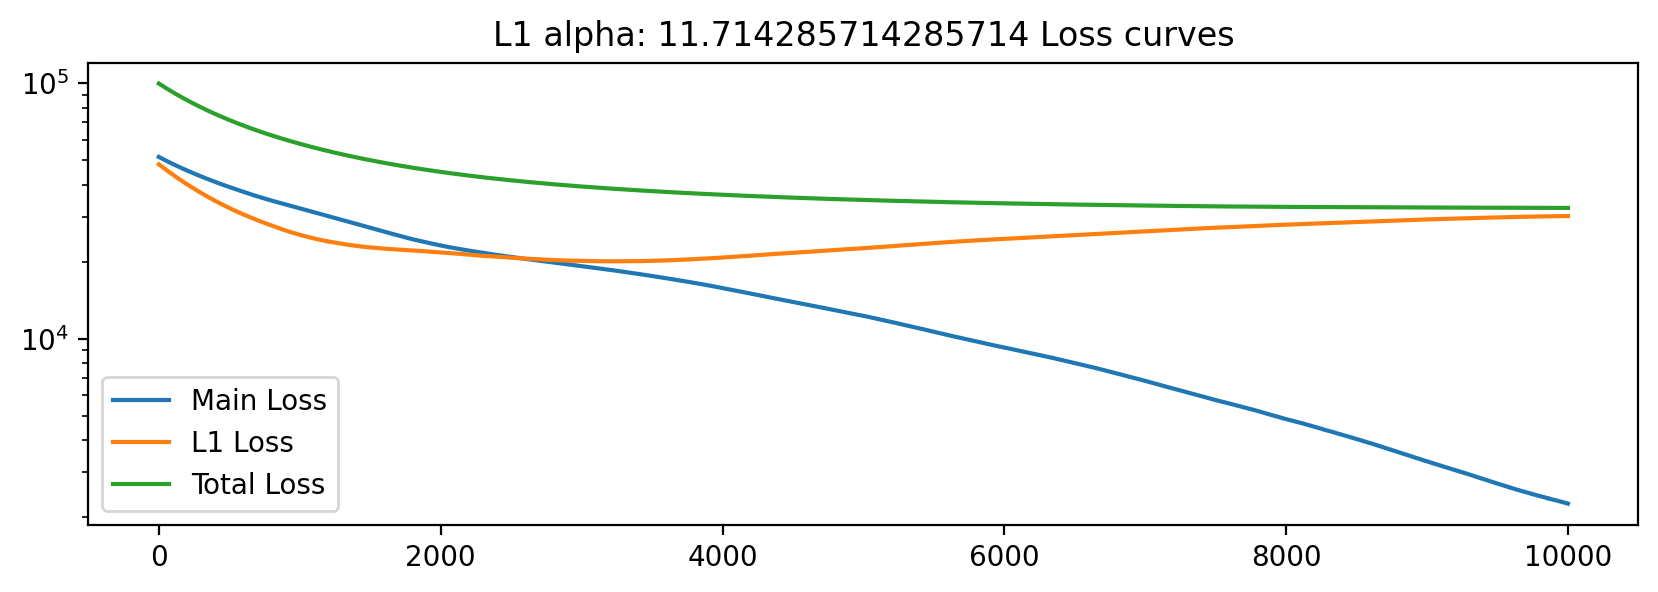

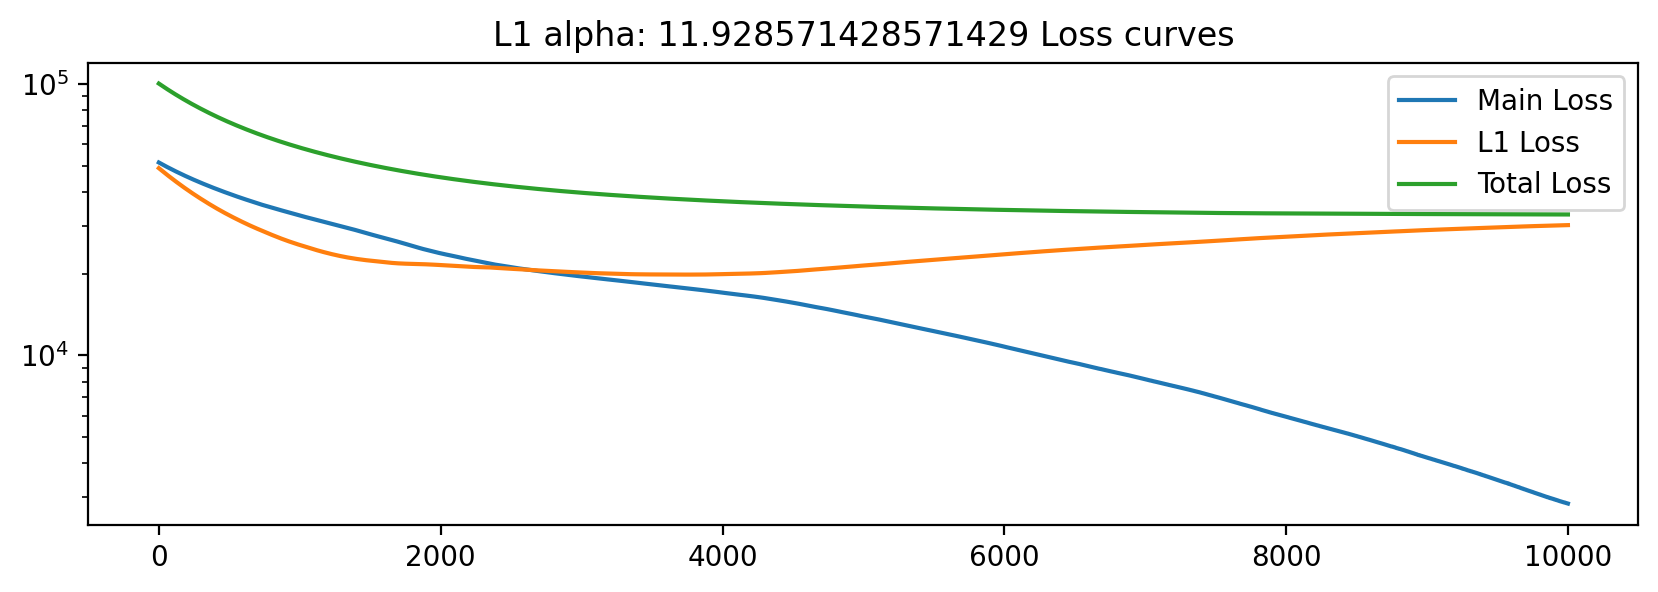

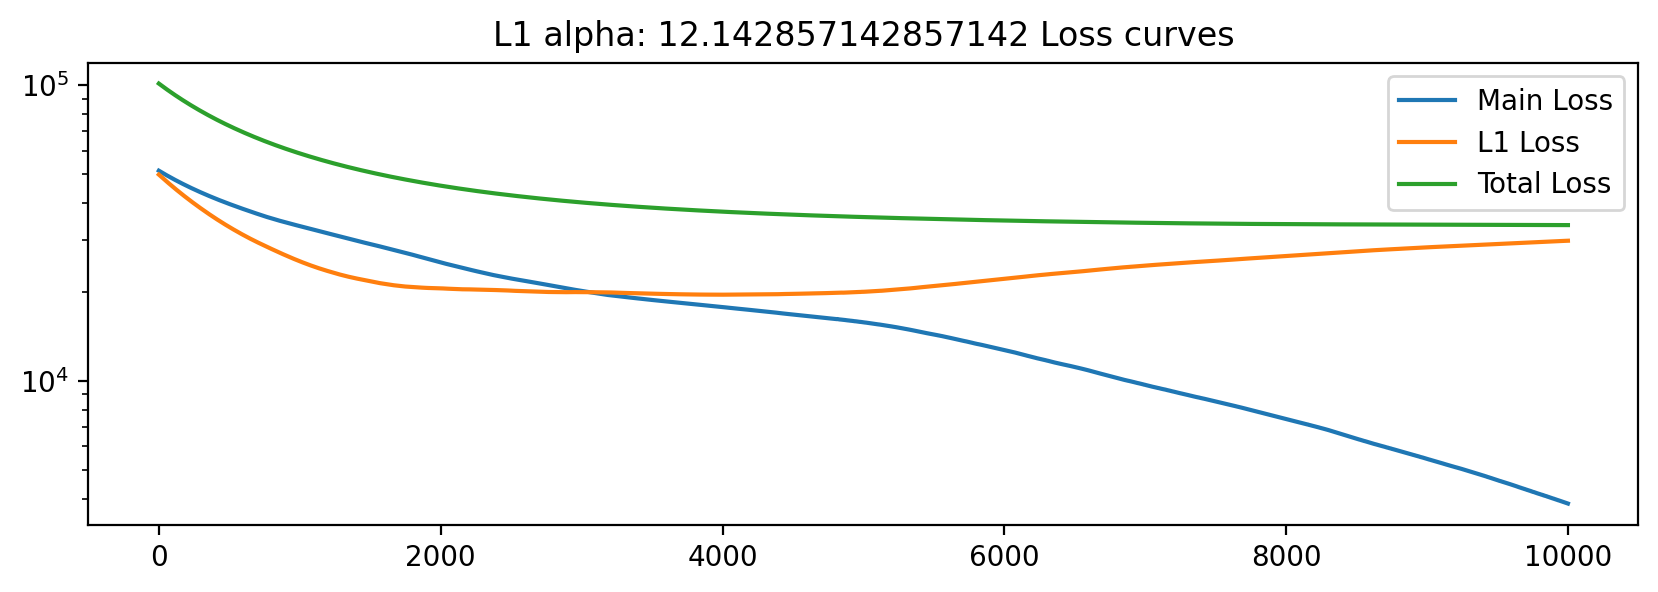

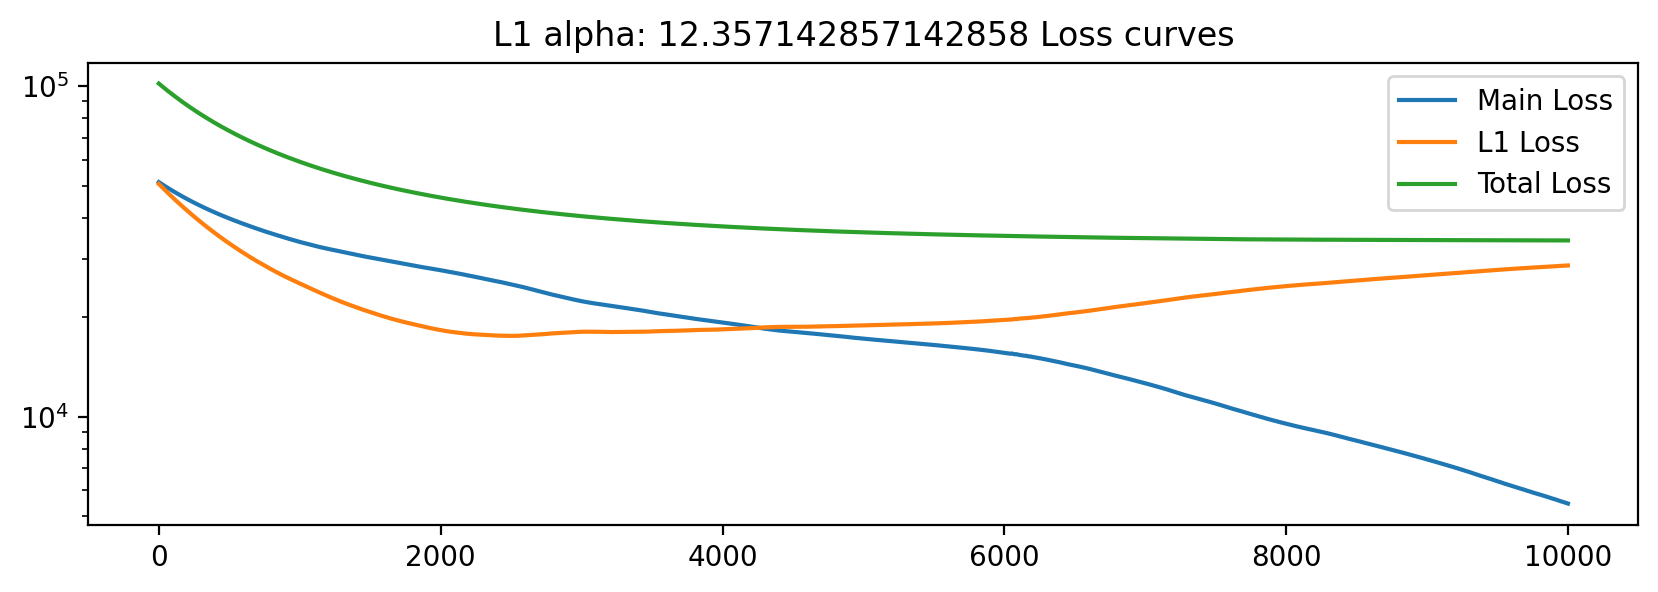

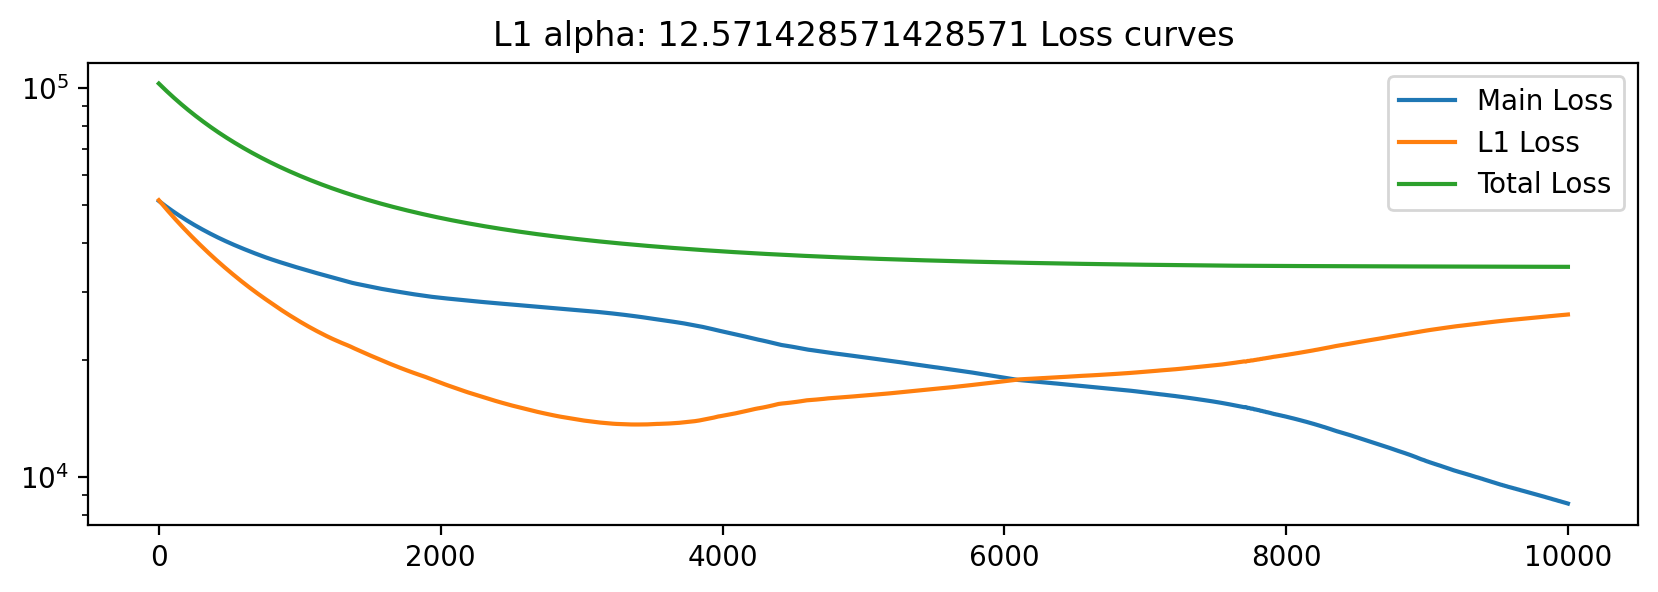

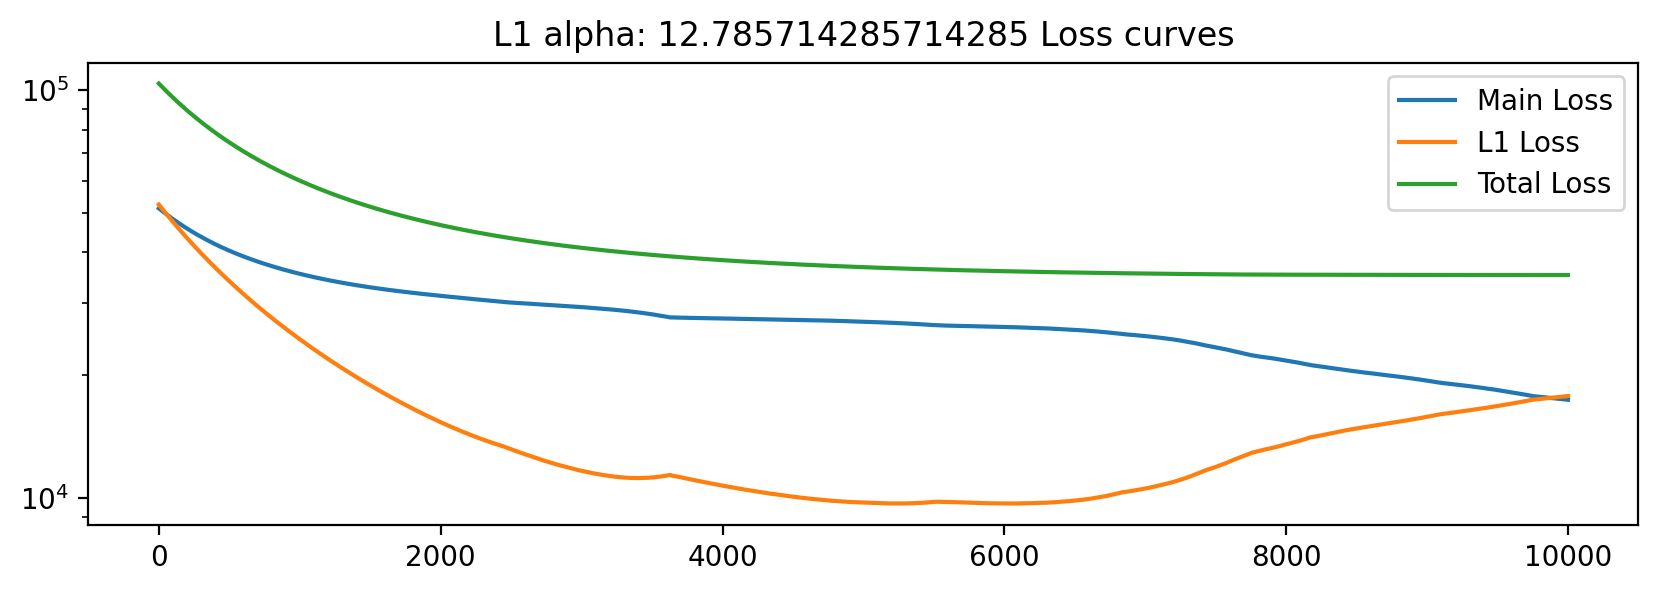

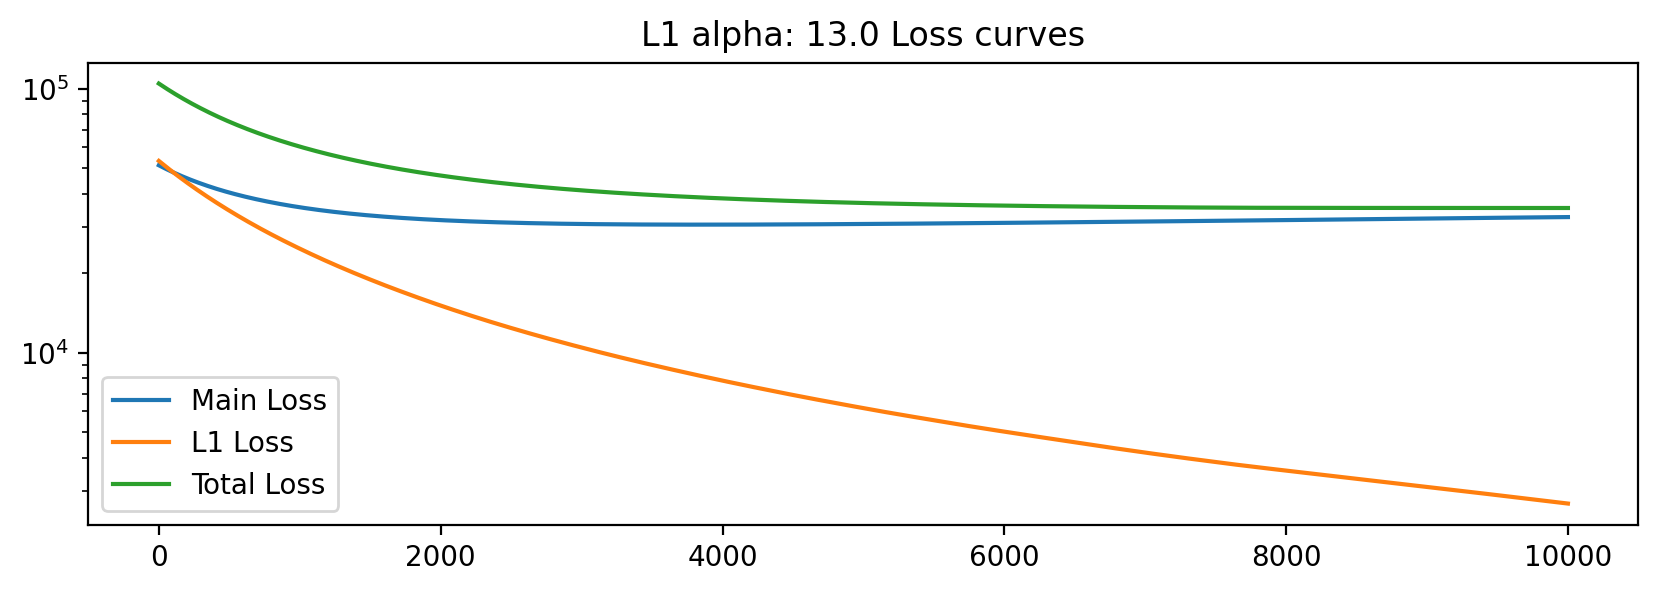

In [7]:
# Initial solution
device = torch.device("cuda")

Y = torch.tensor(trace).double().to(device)
C = torch.tensor(C_numpy).double().to(device)

iterations = 1E4
lr = 1E-3 # 1E-3 is a hard upper limit on LR while converging to solutions
# l1_alphas = [0] + np.logspace(-1, 1, 3).tolist() + np.logspace(1, 2, 3).tolist()
l1_alphas = [0] + np.linspace(10, 13, 15).tolist()
plot_n = 10
printn = 100

# print(model.parameters())

deconvs = []

for l1_alpha in l1_alphas:
    losses = []
    main_losses = []
    l1_losses = []
    
    trace_over_time = []
    magnitudes = []

    model = ExpPosLinear(trace.size)
    # model.set_weights(deconv0, device=device)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for i in range(int(iterations)):
    
        Yp = model(C)
        residual = Yp - Y
        
        loss = 0
        
        # MSE Loss
        # mse_loss = torch.sum((residual)**2) # MSE
        # loss = mse_loss
        # main_losses.append(mse_loss.detach().item())
        
        linear_loss = torch.sum(torch.abs(residual))
        loss += linear_loss
        main_losses.append(linear_loss.detach().item())
    
        # Penalize density
        # TODO try loss += sum(alpha_t * sigmoid(beta_t * weights)) alpha or beta better? Both?
        # L1 Loss
        l1_loss = l1_alpha * torch.sum(model.linear_mag(detach=False))
        loss += l1_loss
        l1_losses.append(l1_loss.detach().item())
    
        # Backpropogate
        losses.append(loss.detach().item())
        loss.backward(retain_graph=True)
        optimizer.step()
        optimizer.zero_grad()
        
        if (i) % (iterations//printn) == 0:
            print(i, loss.detach().cpu().item())
            
    fig = plt.figure(figsize=(10,3), dpi=200)
    plt.title('L1 alpha: {} Loss curves'.format(l1_alpha))
    plt.plot(main_losses, label='Main Loss')
    plt.plot(l1_losses, label='L1 Loss')
    plt.plot(losses, label='Total Loss')
    plt.yscale('log')
    plt.legend()
    
    deconv1 = model.linear_mag()
    deconvs.append(deconv1)
    

Text(0.5, 0, 'Microseconds')

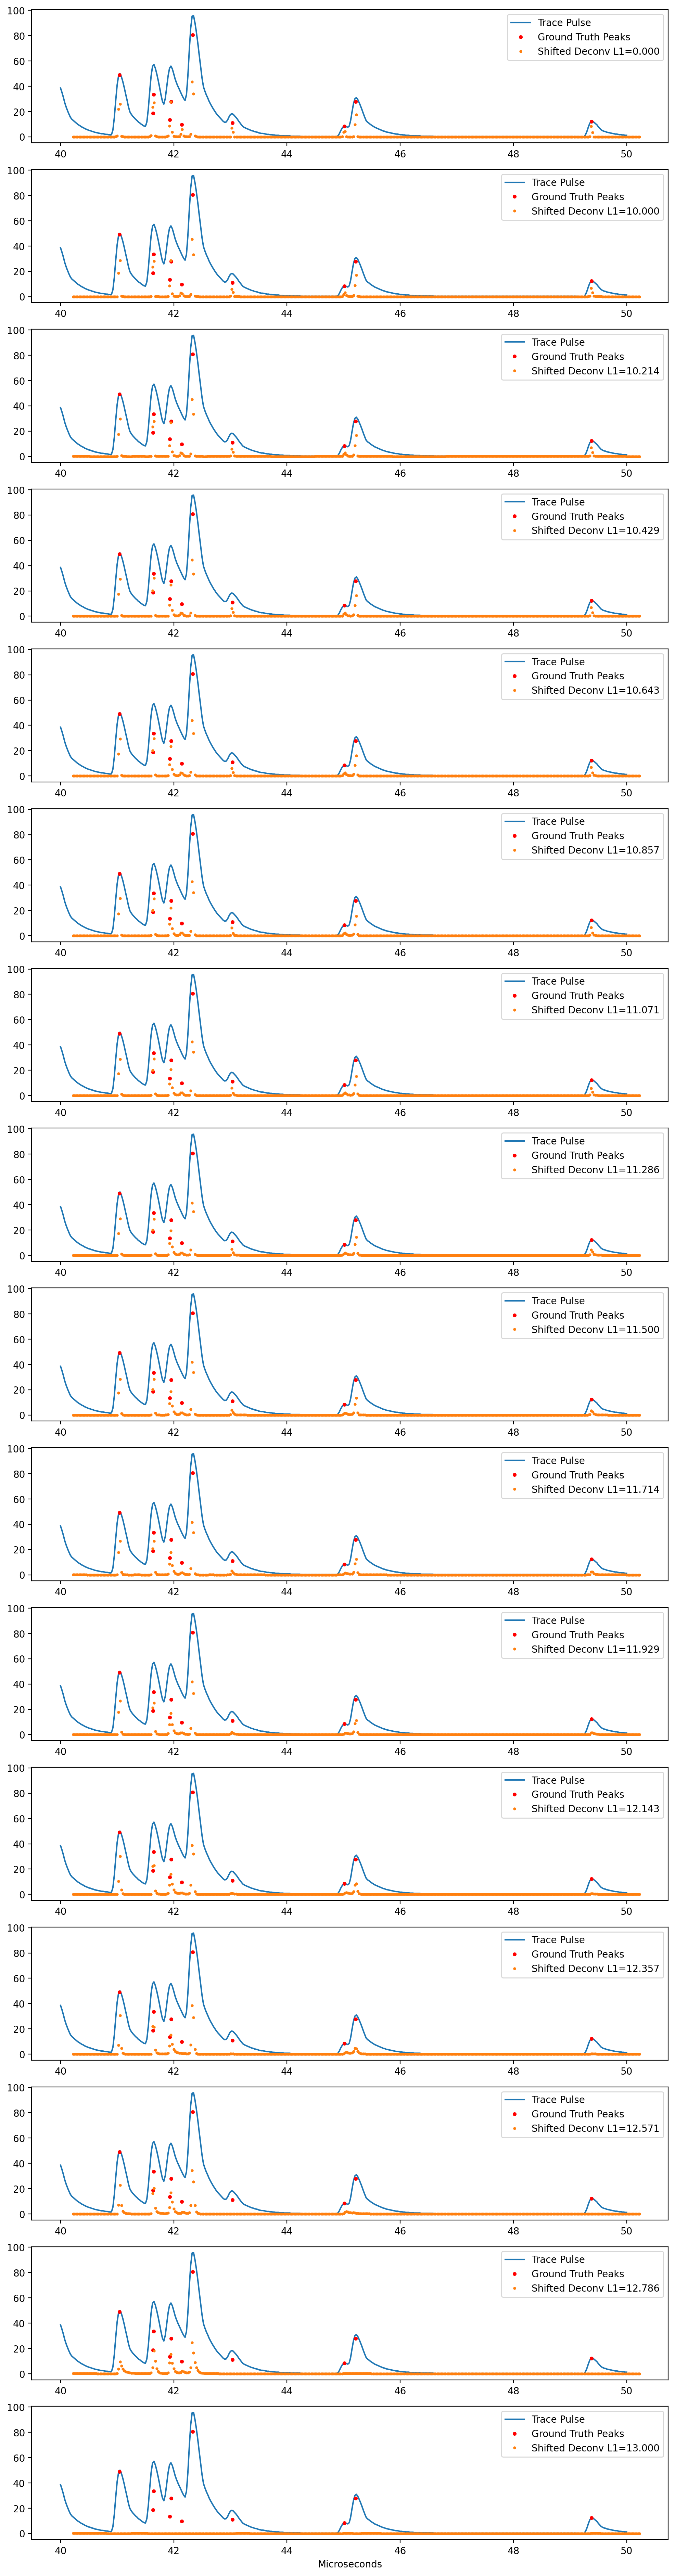

In [17]:
# lim =(0, 10)
# lim = (10, 30)
# lim = (30, 40)
lim = (40, 50)
# lim = (50, 60)
# lim = (70,80)
# lim = (74,77)
# lim = (0,100)

n = len(deconvs)
fig, axes = plt.subplots(n, 1, figsize=(12, n * 3), dpi=200)

for i in range(len(l1_alphas)):
    um = 1E6*(sample_t)
    mask = np.logical_and(lim[0] <= um, um <=lim[1])
    axes[i].plot(um[mask], trace[mask], label='Trace Pulse')
    
    um = 1E6*(event_times)
    mask = np.logical_and(lim[0] <= um, um <=lim[1])
    axes[i].plot(um[mask] + 1E6*peak_offset_time, event_voltages[mask], 'r.', label='Ground Truth Peaks')

    alpha = l1_alphas[i]
    um = 1E6*(sample_t)
    mask = np.logical_and(lim[0] <= um, um <=lim[1])
    axes[i].plot(um[mask] + 1E6*peak_offset_time, deconvs[i][mask], marker='.', markersize=4, linestyle='', label='Shifted Deconv L1={:.3f}'.format(alpha))
    
    axes[i].legend()
    
axes[i].set_xlabel('Microseconds')

In [9]:
# for deconv in deconvs:
#     # Get the index of nonzero values
#     thresh = 1
#     gt1_index = np.where(deconv > thresh)[0]
#     
#     # where diff != 1, there is a gap...
#     gaps = np.where(diff(gt1_index))[0]
#     groups = []
#     for i in gaps.size:
#         gap = gaps[i]
#         groups.append()
#         
#     

In [10]:
# fig = plt.figure(figsize=(10,4), dpi=200)
# plt.plot(mse_losses, label='MSE Losses')
# plt.plot(l1_losses, label='L1 Losses')
# plt.plot(losses, label='Total Loss')
# plt.yscale('log')
# plt.legend()

In [11]:
# deconv1 = model.linear_mag()
# 
# fig = plt.figure(figsize=(12,6), dpi=200)
# plt.plot(1E6*(sample_t), trace, label='Trace Pulse')
# plt.plot(1E6*(sample_t+peak_offset_time), deconv1, marker='.', markersize=1, linestyle='', color='orange', label='Shifted Deconv')
# plt.plot(1E6*(event_times+peak_offset_time), event_voltages, 'r.', label='Ground Truth Peaks')
# plt.plot()
# plt.xlabel('Microseconds')
# plt.legend()
# # plt.xlim(0, 10)
# # plt.xlim(10,20)
# # plt.xlim(20,30)
# # plt.xlim(30, 40)
# # plt.xlim(40, 50)
# # plt.xlim(70, 80)

In [12]:
# TODO new ideas

"""
Problem: Do actual traces approximately follow this constant rate structure?
Or rather, can we even make good countrates estiamtes that can be used locally...?

Can we do rate estimation by "chunking/binning" events in time at different rates relative to some length
scale?

Could try to model inter-nonzero rates as exponential(True) + gaussian(deconv spread)

MC Sampling based deconv
Idea: Provide high density time "gaussian priors" that act as kernels with which to reconstruct traces
Advantages: Can account for noise and countrate directly
            More "real" answer than MLE/MAP point estimates for wide/skewed distributions...
            Can account for probability of events being temporally binned together based on countrate
            Can allow "time drift" of estimates
Disadvantages: Slow AF
            Convergence at high count rates?
Questions: How do we associate time and magnitude variables together?
               - Could be forced together via soft gaussian kernels. If multiple kernels converge
                 then they should probably be grouped. Think particle filter...
               - Could eliminate mag for single var: time by assuming pulses have small magnitude (ex. ~1).
                 Magnitude should be inferred post hoc by density of micropulses in time
               - More accurate stats question is: into how many events should a particular pileup group be split?

intial deconv
|
v
Countrate Estimation:
    MC Sampling w/ Noise?
|
v
-Exponential or convolutional Poisson penalty of L1 reg.
-2D (Time/Mag) optimization doing FFT/IFFT or other interp
-Horseshoe regularization?
-sum_N_adjacent

OTHER ***********************************************8
Iterated subtraction
Iterated (Time, Mag) optimzation adding points one by one...
Apply Gaussian filters to all methods?
Discretize deconv output with signal peak finding. Use as initial soln N for opt(time, mag)
opencv template matching (only for isolated events though?)
Gaussian smoothing
Deconv with purposefully incorrect kernel (stretched/compressed)
What if we optimzied N pulses of magntiude 1 only in time? Might give us a better idea of where to discretize solution...
    - Might be less efficient than doing N(time, mag) together
    
Just do peak finding of deconv to estimate where there are events then resolve with only those times unmasked

# Better Algorithm
init_deconv = TD_Deconv(Trace)
initial N:(T,V) event pairs <- CONVSUM(2 or 3, init_deconv)

while no residual density > threshold:
    for each region of residual density:
        Add (T,V) to minimize residual with all other events locked
        re-optimize all events
        
    # Can we define a prob hypothesis P(another particle) vs P(error)


"""

'\nProblem: Do actual traces approximately follow this constant rate structure?\nOr rather, can we even make good countrates estiamtes that can be used locally...?\n\nCan we do rate estimation by "chunking/binning" events in time at different rates relative to some length\nscale?\n\nCould try to model inter-nonzero rates as exponential(True) + gaussian(deconv spread)\n\nMC Sampling based deconv\nIdea: Provide high density time "gaussian priors" that act as kernels with which to reconstruct traces\nAdvantages: Can account for noise and countrate directly\n            More "real" answer than MLE/MAP point estimates for wide/skewed distributions...\n            Can account for probability of events being temporally binned together based on countrate\n            Can allow "time drift" of estimates\nDisadvantages: Slow AF\n            Convergence at high count rates?\nQuestions: How do we associate time and magnitude variables together?\n               - Could be forced together via soft g